In [27]:
import keras
from keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

C:\Users\Patrik\anaconda3\envs\keras\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
x_train=x_train/255
x_test=x_test/255

y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

Initial model to get a baseline understanding of the performance.

In [4]:

model = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
    ])


In [6]:
model.compile(
    loss=keras.losses.CategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [7]:
history = model.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.3148 - loss: 1.9299 - val_accuracy: 0.3504 - val_loss: 1.8109
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.3777 - loss: 1.7427 - val_accuracy: 0.3934 - val_loss: 1.7080
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4012 - loss: 1.6857 - val_accuracy: 0.4009 - val_loss: 1.6820
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4235 - loss: 1.6294 - val_accuracy: 0.4092 - val_loss: 1.6526
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4355 - loss: 1.5907 - val_accuracy: 0.4149 - val_loss: 1.6695
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4459 - loss: 1.5638 - val_accuracy: 0.4252 - val_loss: 1.6220
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4564 - loss: 1.5390 - val_accuracy: 0.4297 - val_loss: 1.6085
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4596 - loss: 1.5212 - val_acc

In [8]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 1s - 4ms/step - accuracy: 0.4565 - loss: 1.5441
Test loss: 1.5440694093704224
Test accuracy: 0.45649999380111694


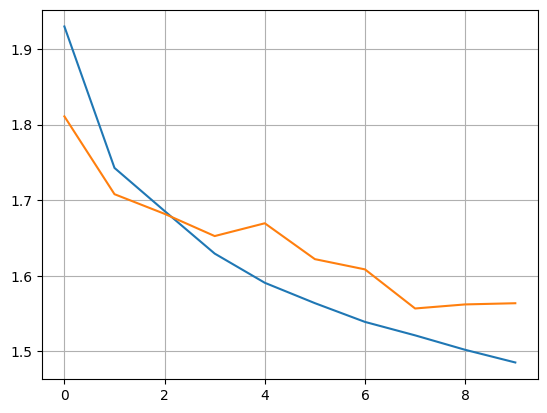

In [9]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()

The model shows acceptable relation between its improvement in minimising test and validation loss.  
To improve on the model an additional hidden layer will be introduced and 10% of all the neurons in the first hidden layer will be randomly chosen as inactive.  
The ultimate trajectory of validation loss graph is still unclear and for that reason the amount of epochs will be also increased.  

In [10]:
model = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.1),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
    ])


In [11]:
model.compile(
    loss=keras.losses.CategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [12]:
history = model.fit(x_train, y_train, batch_size=64, epochs=50, validation_split=0.2, verbose=0)

In [13]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 1s - 4ms/step - accuracy: 0.5009 - loss: 1.4177
Test loss: 1.4177464246749878
Test accuracy: 0.5008999705314636


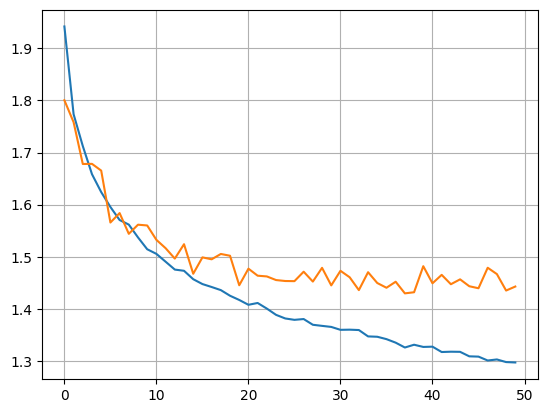

In [14]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()

While the model is improved from the previous version.  
However this can most likely be attributed to the increase in training time, rather than any optimisation in the training process itself.  
The graph indicates that validation loss continues to lower in value well into around the 20. epoch mark.  

To test further optimisation in the training process the batches will be normalised after the second hidden layer and 10% of its neurons will also ignored.  
In addition, now that there's a clear indication of an optimal point for the amount of epochs an automated stop point will be introducted into the training.  

In [15]:
model = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.1),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(10, activation='softmax')
    ])

In [16]:
model.compile(
    loss=keras.losses.CategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [17]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10)
history = model.fit(x_train, y_train, epochs=500, batch_size=64, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.3053 - loss: 1.9440 - val_accuracy: 0.3306 - val_loss: 1.8673
Epoch 2/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.3629 - loss: 1.7719 - val_accuracy: 0.4050 - val_loss: 1.6828
Epoch 3/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.3900 - loss: 1.7027 - val_accuracy: 0.4027 - val_loss: 1.6944
Epoch 4/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4100 - loss: 1.6458 - val_accuracy: 0.4325 - val_loss: 1.6008
Epoch 5/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.4213 - loss: 1.6160 - val_accuracy: 0.4355 - val_loss: 1.5731
Epoch 6/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.4310 - loss: 1.5839 - val_accuracy: 0.4271 - val_loss: 1.5944
Epoch 7/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.4390 - loss: 1.5623 - val_accuracy: 0.4210 - val_loss: 1.6198
Epoch 8/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4452 - loss: 1.5484 -

In [18]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 1s - 3ms/step - accuracy: 0.4922 - loss: 1.4374
Test loss: 1.4373769760131836
Test accuracy: 0.49219998717308044


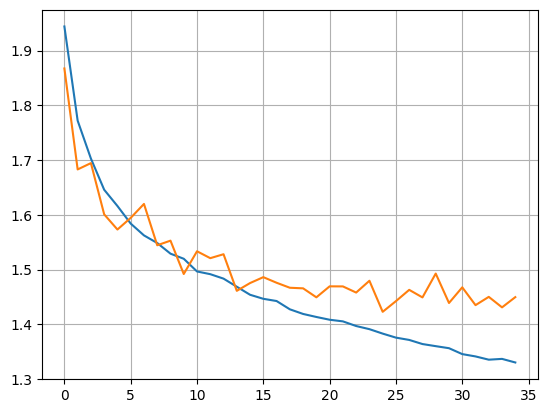

In [19]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()

Results continue to be extremely similiar between all the models.  
Which only leaves the size of the neural network as the untested variable itself.  

The size of the hidden layers will be drastically increased for the final model as well as introducing two more into the model.  
The hidden layers will get smaller in size as the model progresses through the layers, which should give the model its best chance to pick the most significant details out of the pictures and eliminate the irrelevant ones throughout the training process.  

In [42]:
model = Sequential([
    Input(shape=(32, 32, 3)),
    Flatten(),
    Dense(2048, activation='relu'),
    Dropout(0.2),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
    ])


In [43]:
model.compile(
    loss=keras.losses.CategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [44]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10)
history = model.fit(x_train, y_train, epochs=500, batch_size=64, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 126ms/step - accuracy: 0.2947 - loss: 1.9664 - val_accuracy: 0.2932 - val_loss: 1.9195
Epoch 2/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - accuracy: 0.3662 - loss: 1.7584 - val_accuracy: 0.3264 - val_loss: 1.8843
Epoch 3/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - accuracy: 0.3864 - loss: 1.7036 - val_accuracy: 0.3167 - val_loss: 1.9260
Epoch 4/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 118ms/step - accuracy: 0.4081 - loss: 1.6443 - val_accuracy: 0.4259 - val_loss: 1.6026
Epoch 5/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 119ms/step - accuracy: 0.4238 - loss: 1.6003 - val_accuracy: 0.4400 - val_loss: 1.5912
Epoch 6/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 120ms/step - accuracy: 0.4331 - loss: 1.5682 - val_accuracy: 0.4473 - val_loss: 1.5372
Epoch 7/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 119ms/step - accuracy: 0.4428 - loss: 1.5471 - val_accuracy: 0.4117 - val_loss: 1.6418
Epoch 8/500
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 119ms/step - accuracy: 0.4496 -

In [45]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 4s - 12ms/step - accuracy: 0.5184 - loss: 1.3733
Test loss: 1.3732612133026123
Test accuracy: 0.5184000134468079



0 	airplane  
1 	automobile  
2 	bird  
3 	cat  
4 	deer  
5 	dog  
6 	frog  
7 	horse  
8 	ship  
9 	truck  


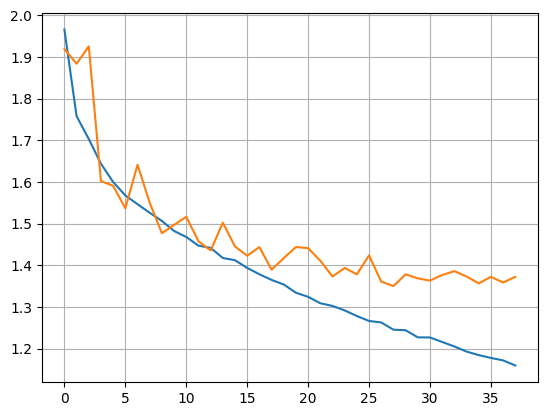

In [47]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()

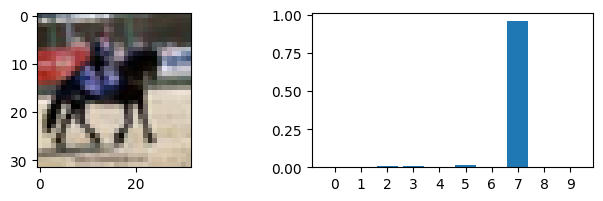

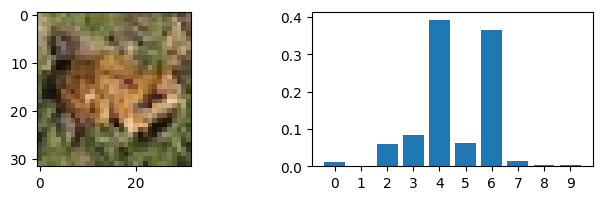

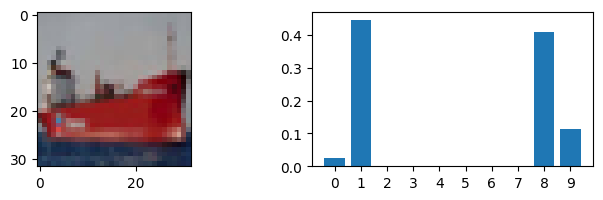

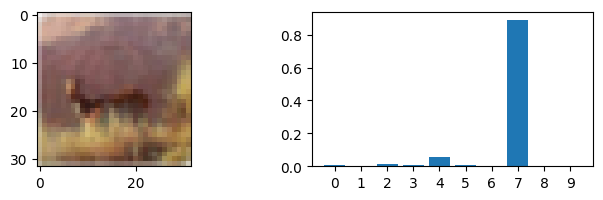

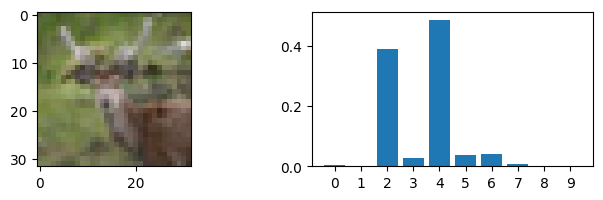

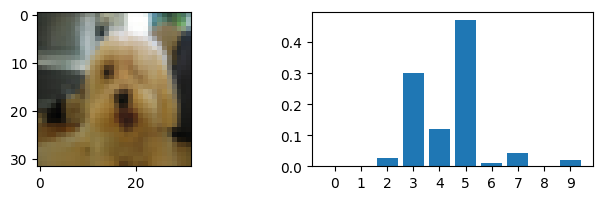

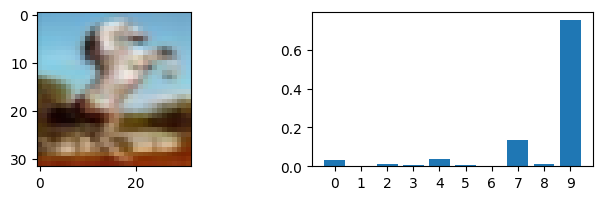

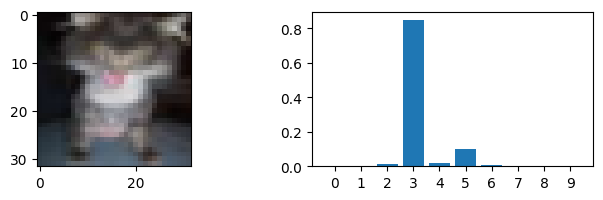

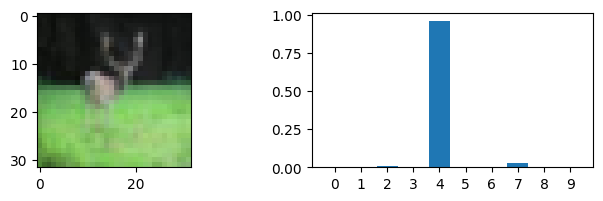

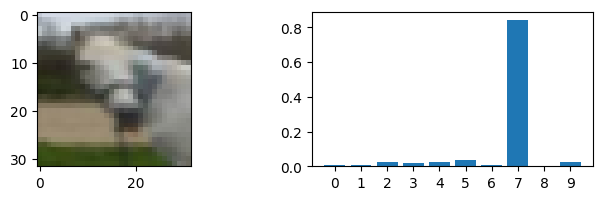

In [51]:
x = x_test
y = model(x)
start = 5000

for k in range(10):
    plt.figure(figsize=(8, 2))
    plt.subplot(1,2,1)
    plt.imshow(x[start+k].reshape((32, 32, 3)))
    ind = np.arange(0, 10)
    plt.subplot(1,2,2)
    plt.bar(ind, y[start+k].numpy().flatten())
    plt.xticks(range(10))

# Conclusions

It is clear that in the process of vectorising a complex image with a subject and colour the features of the image become unrecognizeable to the model to properly parse and to find connections in.  This method is simply not effective in cases where the distinction between the features in the image is not binary.  

This does not prove to be an issue for CNN as its functionality is based on combing through the image with different kinds of filters do make distinctions between the image features.  
This is also another one of the strengths of CNN as opposed to fully connected networks. In fully connected networks the only parameters available for adjusting are tied to the neurons, whereas with CNN the filter itself can be altered either by its dimentions or in the way it catalogues information.